# VulReasoner on SRDatalog

## Semantic gap, provenance-preserving lowering, exact parity, and scale

This notebook explains and validates the interval-valued VulReasoner port in `minimal_vulreasoner/`. It is grounded in the checked-in PyReason rules, annotation callback, SRDatalog query, default `CWE_121_MVP2.graphml`, and the shared deterministic stress generator.

The central result is that one PyReason rule hides **two different aggregates**. SRDatalog must preserve their grouping boundary:

1. **within one rule and head key:** score each derivation witness, then select one witness by `ARG MAX(lower)`;
2. **across rules for the same `AnalystAt` key:** intersect the already-selected intervals.

Collapsing these into one duplicate-handling operation changes the answer. The executable sections below exhibit the counterexample, show the two-rule lowering, compare canonical result bytes on the default graph, and report bounded scaling measurements.

> Kernel: select **srdatalog VulReasoner (.venv-vulreasoner, Python 3.10)**. The first code cell rejects any other interpreter. PyReason's Numba fixed-point kernel does not compile under the checkout's existing Python 3.12 `.venv`. The notebook contains the verified 2026-07-16 snapshot so ordinary **Run All** is fast. Set `VULREASONER_NOTEBOOK_LIVE=1` before starting Jupyter to rerun PyReason and the cached CUDA artifact. Live PyReason subprocesses have a 120-second suite timeout.

In [1]:
from __future__ import annotations

import csv
import hashlib
import inspect
import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'minimal_vulreasoner').is_dir() and (candidate / 'src' / 'srdatalog').is_dir():
            return candidate.resolve()
    raise RuntimeError('Run this notebook from the srdatalog-python checkout.')

REPO = find_repo_root()
EXPECTED_VENV = (REPO / '.venv-vulreasoner').resolve()
ACTIVE_PREFIX = Path(sys.prefix).resolve()
if ACTIVE_PREFIX != EXPECTED_VENV:
    raise RuntimeError(
        f'Wrong notebook kernel: {sys.executable}. Select srdatalog VulReasoner '
        f'(.venv-vulreasoner, Python 3.10); '
        f'expected prefix {EXPECTED_VENV}, got {ACTIVE_PREFIX}.'
    )
for path in (REPO, REPO / 'src'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

MINIMAL = REPO / 'minimal_vulreasoner'
RULES_FILE = MINIMAL / 'rules' / 'analyst_rules.csv'
LIVE = os.environ.get('VULREASONER_NOTEBOOK_LIVE') == '1'
PYREASON_SUITE_TIMEOUT_SECONDS = 120
PYREASON_MAX_TRANSITIONS = 12_288

print('repository :', REPO)
print('kernel     :', sys.executable)
print('data mode  :', 'LIVE engines' if LIVE else 'verified snapshot')
print('PyReason guard:', PYREASON_SUITE_TIMEOUT_SECONDS, 'seconds and', f'{PYREASON_MAX_TRANSITIONS:,}', 'transitions')

repository : /home/stargazermiao/workspace/srdatalog-python
kernel     : /home/stargazermiao/workspace/srdatalog-python/.venv-vulreasoner/bin/python
data mode  : LIVE engines
PyReason guard: 120 seconds and 12,288 transitions


## 1. The semantic gap

Classical positive Datalog gives each predicate a **set of tuples** and computes a least fixed point. Duplicate derivations of the same tuple are observationally identical. VulReasoner needs more structure:

| Concern | Plain Datalog | VulReasoner requirement | SRDatalog representation |
|---|---|---|---|
| fact value | present / absent | confidence interval $[l,u]$ | two value columns `lower`, `upper` |
| logical time | absent or external | rule delay `<-1` | explicit `time` key plus `Successor(t,t1)` |
| body result | substitution | substitution plus supporting tuples and their intervals | join row / derivation witness |
| duplicates within one rule | collapse | choose the best supporting witness | rule-local candidate relation |
| duplicates from different rules | collapse | accumulate information by interval intersection | `AnalystAt` lattice merge |

A satisfied body is both a relational **join result** and a **why-provenance witness**. Its tuple identities matter because the returned upper bound must come from the same witness whose lower bound won. Merely retaining a bag of lower and upper values loses that association.

### Why this is not traditional semiring provenance

In a traditional $K$-relation or provenance-polynomial interpretation, every input tuple $t$ receives a token $x_t$. A conjunctive derivation multiplies the tokens of its jointly used tuples, and alternative derivations of the same output are added:

$$\operatorname{Prov}(k)=\bigoplus_{w\in W_k}\;\bigotimes_{t\in w}x_t.$$

For the free provenance semiring $\mathbb{N}[X]$, this expression preserves the alternative derivation monomials. More generally, a $K$-relation supplies **one global** $\oplus$ for all duplicate derivations, regardless of which rule produced them. Query evaluation is compositional: it combines annotations with $\otimes$ and $\oplus$ rather than giving user code the grounded source tuples so it can inspect their values and identities.

VulReasoner does something structurally different:

$$\operatorname{AnalystAt}(k)=\bigsqcup_I{}_r\; I\!\left(\operatorname*{arg\,max}_{w\in W_{r,k}}(\operatorname{lower}(I(w)),-\operatorname{rank}(w))\right).$$

The alternatives are first **partitioned by source rule**. Within a partition, the callback compares numeric interval payloads, selects one witness, carries that witness's correlated upper bound, and discards the losing witnesses. Only afterward are winners from different rules combined by the different operation $\sqcup_I$ (interval intersection). Consequently no single semiring addition can represent both duplicate cases: choosing `max` globally would wrongly make different rules compete, while using interval intersection globally would wrongly merge losing witnesses from the same rule.

The connector rank retained by SRDatalog is therefore a selection/tie-break key, not a provenance variable, and the result does not contain a provenance polynomial or the set of all supporting derivations. The computation is **provenance-aware** because witness identity affects which interval survives; it is not traditional semiring-provenance processing. One could design a richer nested algebra carrying rule identities and witnesses, but that would be an explicit extension beyond ordinary $K$-relations, not merely 'use intervals as the provenance semiring.'

The port is therefore best understood as *lattice-valued recursive Datalog with a rule-local grouped aggregate*, not as Boolean Datalog with two decorative columns.

In [2]:
with RULES_FILE.open(newline='') as handle:
    original_rules = list(csv.DictReader(handle))

original_df = pd.DataFrame(
    {
        'name': row['name'],
        'original PyReason rule': row['rule_text'],
    }
    for row in original_rules
)
pd.set_option('display.max_colwidth', 180)
display(original_df)
assert len(original_df) == 6

,name,original PyReason rule
0,analyst-rule-1,"analystAt(CB2):paired_minimum_bounds_ann_fn <-1 analystAt(CB1):[0.25,1], hasLabel(CB1, Lcause):[0.1,1], hasLabel(CB2, Leffect):[0.1,1], can_cause(Lcause, Leffect):[0.1,1], step..."
1,analyst-rule-2,"analystAt(CB2):paired_minimum_bounds_ann_fn <-1 analystAt(CB1):[0.25,1], hasLabel(CB1, Lcontrib):[0.1,1], hasLabel(CB2, Lfault):[0.1,1], contributes_to(Lcontrib, Lfault):[0.1,1..."
2,analyst-rule-3,"analystAt(CB2):paired_minimum_bounds_ann_fn <-1 analystAt(CB1):[0.25,1], hasLabel(CB1, Lop):[0.1,1], hasLabel(CB2, Lderived):[0.1,1], derives(Lop, Lderived):[0.1,1], stepFrom(C..."
3,analyst-rule-4,"analystAt(CB2):paired_minimum_bounds_ann_fn <-1 analystAt(CB1):[0.25,1], hasLabel(CB1, Lunsafe):[0.1,1], hasLabel(CB2, Lsafe_concept):[0.1,1], unsafe_variant_of(Lunsafe, Lsafe_..."
4,analyst-rule-5,"analystAt(CB2):paired_minimum_bounds_ann_fn <-1 analystAt(CB1):[0.25,1], hasLabel(CB1, Lfault):[0.1,1], hasLabel(CB2, Lcwe):[0.1,1], manifestation_of(Lfault, Lcwe):[0.1,1], ste..."
5,analyst-rule-6,"analystAt(CB2):paired_minimum_bounds_ann_fn <-1 analystAt(CB1):[0.25,1], hasLabel(CB1, Lfunc):[0.1,1], hasLabel(CB2, Lop):[0.1,1], implements(Lfunc, Lop):[0.1,1], stepFrom(CB1,..."


## 2. What the PyReason annotation callback actually computes

For a fixed rule $r$, output key $k=(CB2,t+1)$, and witness set $W_{r,k}$, the callback implements:

$$I(w)=[\min(l_c,l_e,l_d),\;\min(u_c,u_e,u_d)]$$

$$w^*_{r,k}=\operatorname*{arg\,max}_{w\in W_{r,k}}(\operatorname{lower}(I(w)),-\operatorname{rank}(w)),\qquad C_r(k)=I(w^*_{r,k}).$$

Here $c$, $e$, and $d$ are the matched cause-label, effect-label, and connector tuples. The componentwise `min` is the interval extension of a Gödel-style conjunction used by this application; it is **not** interval intersection. `rank` makes PyReason's first-witness tie behavior deterministic and is not evidence strength.

The six-argument PyReason callback is unusual because `annotations[i]` alone is a flattened per-clause collection. `qualified_edges`, `clause_labels`, and `clause_variables` recover which `hasLabel` facts belong to each connector pair. This is limited provenance-aware selection: it remembers enough tuple identity to select correctly, but it is not full semiring provenance and does not retain every derivation polynomial.

The next cell prints the exact callback used by the example.

In [3]:
from minimal_vulreasoner.annotation_fn import paired_minimum_bounds_ann_fn

print(inspect.getsource(paired_minimum_bounds_ann_fn.py_func))

@numba.njit
def paired_minimum_bounds_ann_fn(
    annotations, weights, qualified_nodes, qualified_edges, clause_labels, clause_variables
):
    head_var_x = "CB1"
    head_var_y = "CB2"

    driver_idx = -1
    has_label_cb1_idx = -1
    has_label_cb2_idx = -1

    for i in range(len(clause_labels)):
        name = clause_labels[i].value
        cv = clause_variables[i]
        if name == "hasLabel" and len(cv) == 2:
            if cv[0] == head_var_x:
                has_label_cb1_idx = i
            elif cv[0] == head_var_y:
                has_label_cb2_idx = i
        elif name != "analystAt" and name != "stepFrom":
            if (
                len(cv) == 2
                and cv[0] != head_var_x and cv[0] != head_var_y
                and cv[1] != head_var_x and cv[1] != head_var_y
            ):
                driver_idx = i

    if driver_idx < 0 or has_label_cb1_idx < 0 or has_label_cb2_idx < 0:
        return 0.0, 1.0

    best_lower = 0.0
    best_upper = 0.0
    found_

### The second aggregate is different

Once each rule has selected its winner, distinct rules may still derive the same `AnalystAt(node,time)` key. PyReason's world update accumulates information using interval intersection:

$$[l_1,u_1]\sqcup_I[l_2,u_2]=[\max(l_1,l_2),\min(u_1,u_2)].$$

Under the information order $[l,u]\sqsubseteq_I[l',u']$ iff $l\le l'$ and $u\ge u'$, a smaller interval is more informative and the operation above is the join. This is the operation used for recursive `AnalystAt` state. It is not the within-rule `ARG MAX`, and applying it to losing witnesses is incorrect.

In [4]:
def score(lower_parts, upper_parts):
    return min(lower_parts), min(upper_parts)

def information_join(intervals):
    return max(i[0] for i in intervals), min(i[1] for i in intervals)

witnesses = [
    {'rule': 'r1', 'head': 'AnalystAt(b2,2)', 'rank': 7, 'lower parts': (0.90, 0.85, 0.80), 'upper parts': (0.98, 0.97, 0.95)},
    {'rule': 'r1', 'head': 'AnalystAt(b2,2)', 'rank': 9, 'lower parts': (0.70, 0.65, 0.60), 'upper parts': (0.88, 0.84, 0.82)},
    {'rule': 'r2', 'head': 'AnalystAt(b2,2)', 'rank': 4, 'lower parts': (0.80, 0.75, 0.70), 'upper parts': (0.92, 0.90, 0.85)},
]
for witness in witnesses:
    witness['witness interval'] = score(witness['lower parts'], witness['upper parts'])
display(pd.DataFrame(witnesses))

r1_rows = [w for w in witnesses if w['rule'] == 'r1']
r1_winner = max(r1_rows, key=lambda w: (w['witness interval'][0], -w['rank']))['witness interval']
r2_winner = witnesses[2]['witness interval']
wrong_direct_merge = information_join([w['witness interval'] for w in r1_rows])
correct_final = information_join([r1_winner, r2_winner])
wrong_global_argmax = max((r1_winner, r2_winner), key=lambda i: i[0])

comparison = pd.DataFrame([
    ('correct r1: select one witness', r1_winner),
    ('wrong r1: intersect both witnesses', wrong_direct_merge),
    ('correct final: intersect rule winners', correct_final),
    ('wrong final: one global ARG MAX', wrong_global_argmax),
], columns=['computation', 'interval'])
display(comparison)
assert r1_winner == (0.80, 0.95)
assert wrong_direct_merge == (0.80, 0.82)
assert correct_final == (0.80, 0.85)
assert wrong_global_argmax == (0.80, 0.95)

,rule,head,rank,lower parts,upper parts,witness interval
0,r1,"AnalystAt(b2,2)",7,"(0.9, 0.85, 0.8)","(0.98, 0.97, 0.95)","(0.8, 0.95)"
1,r1,"AnalystAt(b2,2)",9,"(0.7, 0.65, 0.6)","(0.88, 0.84, 0.82)","(0.6, 0.82)"
2,r2,"AnalystAt(b2,2)",4,"(0.8, 0.75, 0.7)","(0.92, 0.9, 0.85)","(0.7, 0.85)"


,computation,interval
0,correct r1: select one witness,"(0.8, 0.95)"
1,wrong r1: intersect both witnesses,"(0.8, 0.82)"
2,correct final: intersect rule winners,"(0.8, 0.85)"
3,wrong final: one global ARG MAX,"(0.8, 0.95)"


## 3. Why every PyReason rule becomes two SRDatalog rules

For `analyst-rule-1`, PyReason presents one surface rule:

```text
analystAt(CB2):paired_minimum_bounds_ann_fn <-1
  analystAt(CB1):[0.25,1],
  hasLabel(CB1,Lcause):[0.1,1],
  hasLabel(CB2,Leffect):[0.1,1],
  can_cause(Lcause,Leffect):[0.1,1],
  stepFrom(CB1,CB2)
```

Its semantics is made explicit as two rules (shown schematically with interval payloads):

```text
CanCauseCandidate(CB2,t1,rank,l,u) :-
  AnalystAt(CB1,t,la,ua), HasLabel(CB1,Lcause,lc,uc),
  HasLabel(CB2,Leffect,le,ue),
  CanCause(Lcause,Leffect,rank,ld,ud),
  StepFrom(CB1,CB2,t), Successor(t,t1),
  thresholds_hold, l=min(lc,le,ld), u=min(uc,ue,ud).

AnalystAt(CB2,t1,l,u) :- CanCauseCandidate(CB2,t1,rank,l,u).
```

`CanCauseCandidate` is functional by key `(CB2,t1)` and performs `max-lower-select` over `(rank,l,u)`. Its delta contains only the selected winner. The promotion rule is therefore only a projection. Insertion into functional `AnalystAt`, keyed by `(CB2,t1)`, then performs `interval-intersection`.

The **rule identity is part of the grouping context**. Separate candidate relations ensure that two witnesses from the same rule compete, while winners from different rules intersect. A single candidate relation keyed only by the head would wrongly make different rules compete; direct insertion into `AnalystAt` would wrongly intersect losing witnesses. A future fused head-aggregate may remove the temporary materialization, but it cannot remove this semantic boundary.

In [5]:
from minimal_vulreasoner.srdatalog_query import RULE_SPECS, build_analyst_program

program = build_analyst_program()
value_relations = []
for relation in program.relations:
    if relation.name == 'AnalystAt' or relation.name.endswith('Candidate'):
        value_relations.append({
            'relation': relation.name,
            'arity': relation.arity,
            'key columns': relation.value_spec.key_columns,
            'value columns': relation.value_spec.value_columns,
            'duplicate operation': relation.value_spec.join.value,
        })
display(pd.DataFrame(value_relations))

lowering_map = pd.DataFrame([
    {
        'PyReason rule': spec.name,
        'connector': spec.connector_predicate,
        'candidate relation': f'{spec.relation_name}Candidate',
        'SRDatalog join rule': f'Analyst{spec.relation_name}',
        'SRDatalog projection rule': f'Promote{spec.relation_name}Candidate',
    }
    for spec in RULE_SPECS
])
display(lowering_map)
print('Actual program rule order:')
print('  ' + '\n  '.join(rule.name for rule in program.rules))
assert len(program.rules) == 1 + 2 * len(RULE_SPECS)

,relation,arity,key columns,value columns,duplicate operation
0,AnalystAt,4,"(0, 1)","(2, 3)",interval-intersection
1,CanCauseCandidate,5,"(0, 1)","(2, 3, 4)",max-lower-select
2,ContributesToCandidate,5,"(0, 1)","(2, 3, 4)",max-lower-select
3,DerivesCandidate,5,"(0, 1)","(2, 3, 4)",max-lower-select
4,UnsafeVariantOfCandidate,5,"(0, 1)","(2, 3, 4)",max-lower-select
5,ManifestationOfCandidate,5,"(0, 1)","(2, 3, 4)",max-lower-select
6,ImplementsCandidate,5,"(0, 1)","(2, 3, 4)",max-lower-select


,PyReason rule,connector,candidate relation,SRDatalog join rule,SRDatalog projection rule
0,analyst-rule-1,can_cause,CanCauseCandidate,AnalystCanCause,PromoteCanCauseCandidate
1,analyst-rule-2,contributes_to,ContributesToCandidate,AnalystContributesTo,PromoteContributesToCandidate
2,analyst-rule-3,derives,DerivesCandidate,AnalystDerives,PromoteDerivesCandidate
3,analyst-rule-4,unsafe_variant_of,UnsafeVariantOfCandidate,AnalystUnsafeVariantOf,PromoteUnsafeVariantOfCandidate
4,analyst-rule-5,manifestation_of,ManifestationOfCandidate,AnalystManifestationOf,PromoteManifestationOfCandidate
5,analyst-rule-6,implements,ImplementsCandidate,AnalystImplements,PromoteImplementsCandidate


Actual program rule order:
  AnalystSeed
  AnalystCanCause
  PromoteCanCauseCandidate
  AnalystContributesTo
  PromoteContributesToCandidate
  AnalystDerives
  PromoteDerivesCandidate
  AnalystUnsafeVariantOf
  PromoteUnsafeVariantOfCandidate
  AnalystManifestationOf
  PromoteManifestationOfCandidate
  AnalystImplements
  PromoteImplementsCandidate


## 4. Physical interval encoding

Every annotated logical tuple carries its range as **two extra columns**. Examples:

- `HasLabel(block,label,lower_bits,upper_bits)`
- `CanCause(cause,effect,rank,lower_bits,upper_bits)`
- `AnalystAt(node,time,lower_bits,upper_bits)`
- `CanCauseCandidate(node,time,rank,lower_bits,upper_bits)`

Bounds are bit-cast IEEE-754 binary32 words. All application values are in `[0,1]`, so unsigned word order is the same as float order. This lets the generated CUDA path use integer `min`/`max` without changing the logical order, while decoding remains exact.

The two computations over these columns remain distinct: candidate maintenance compares lower values and carries the entire winning `(rank,lower,upper)` payload; `AnalystAt` maintenance computes `(max lower, min upper)`.

In [6]:
from srdatalog import float32_to_u32, u32_to_float32

values = [0.0, 0.1, 0.25, 0.6, 0.8, 1.0]
encoding_df = pd.DataFrame({
    'float bound': values,
    'uint32 word': [float32_to_u32(value) for value in values],
    'decoded float32': [u32_to_float32(float32_to_u32(value)) for value in values],
})
display(encoding_df)
assert encoding_df['uint32 word'].tolist() == sorted(encoding_df['uint32 word'])
assert all(float32_to_u32(decoded) == bits for decoded, bits in zip(encoding_df['decoded float32'], encoding_df['uint32 word']))

,float bound,uint32 word,decoded float32
0,0.00,0,0.00
1,0.10,1036831949,0.10
2,0.25,1048576000,0.25
3,0.60,1058642330,0.60
4,0.80,1061997773,0.80
5,1.00,1065353216,1.00


## 5. Default GraphML: canonical bytes match exactly

The default checked-in input has 188 graph nodes, 403 graph edges, and 138 connector attributes used by the six rules. The expected temporal chain is:

```text
b1@0, b1@1 -> b2@2 -> b3@3 -> b4@4
```

For engine-independent comparison, each result is serialized in sorted order as `node@time,lower_float32_bits,upper_float32_bits\n`. This catches row-set, key, interval, and floating-point representation differences—not merely approximate numeric equality. In live mode, `validate_minimal_parity.py` runs the real PyReason oracle and cached SRDatalog CUDA artifact before this serialization.

In [7]:
VERIFIED_ROWS = {
    'b1@0': [1.0, 1.0],
    'b1@1': [1.0, 1.0],
    'b2@2': [1.0, 1.0],
    'b3@3': [1.0, 1.0],
    'b4@4': [1.0, 1.0],
}

def prefixed_json(stdout: str, prefix: str):
    line = next(line for line in stdout.splitlines() if line.startswith(prefix))
    return json.loads(line.removeprefix(prefix))

if LIVE:
    env = {**os.environ, 'PYTHONPATH': f"{REPO / 'src'}:{REPO}", 'PYTHONHASHSEED': '0'}
    completed = subprocess.run(
        [sys.executable, str(MINIMAL / 'validate_minimal_parity.py'), '--no-compile'],
        cwd=REPO, env=env, text=True, capture_output=True,
        timeout=PYREASON_SUITE_TIMEOUT_SECONDS + 60, check=False,
    )
    if completed.returncode != 0:
        raise RuntimeError(completed.stdout + completed.stderr)
    srdatalog_result = prefixed_json(completed.stdout, 'RESULT_JSON=')
    pyreason_rows = prefixed_json(completed.stdout, 'ANALYST_ROWS=')
    srdatalog_rows = srdatalog_result['analyst_rows']
    parity_mode = 'live PyReason + live cached SRDatalog'
    graph_summary = {key: srdatalog_result[key] for key in ('graph_nodes', 'graph_edges', 'selected_connector_facts')}
else:
    pyreason_rows = dict(VERIFIED_ROWS)
    srdatalog_rows = dict(VERIFIED_ROWS)
    parity_mode = 'verified 2026-07-16 snapshot'
    graph_summary = {'graph_nodes': 188, 'graph_edges': 403, 'selected_connector_facts': 138}

def canonical_result_bytes(rows):
    return b''.join(
        f'{key},{float32_to_u32(bounds[0])},{float32_to_u32(bounds[1])}\n'.encode()
        for key, bounds in sorted(rows.items())
    )

pyreason_bytes = canonical_result_bytes(pyreason_rows)
srdatalog_bytes = canonical_result_bytes(srdatalog_rows)
assert pyreason_bytes == srdatalog_bytes
digest = hashlib.sha256(pyreason_bytes).hexdigest()

display(pd.DataFrame([
    {'engine': 'PyReason', 'rows': len(pyreason_rows), 'bytes': len(pyreason_bytes), 'sha256': hashlib.sha256(pyreason_bytes).hexdigest()},
    {'engine': 'SRDatalog', 'rows': len(srdatalog_rows), 'bytes': len(srdatalog_bytes), 'sha256': hashlib.sha256(srdatalog_bytes).hexdigest()},
]))
print('mode:', parity_mode)
print('input:', graph_summary)
print('byte-for-byte equal: PASS')
print('canonical SHA-256:', digest)
print('\nCanonical result bytes:\n' + pyreason_bytes.decode())
assert digest == 'ae3d94e59f1417f1f7ab264f4bf5146e9e511a4b35c1a351bcc24cb4039d4b2d'

,engine,rows,bytes,sha256
0,PyReason,5,135,ae3d94e59f1417f1f7ab264f4bf5146e9e511a4b35c1a351bcc24cb4039d4b2d
1,SRDatalog,5,135,ae3d94e59f1417f1f7ab264f4bf5146e9e511a4b35c1a351bcc24cb4039d4b2d


mode: live PyReason + live cached SRDatalog
input: {'graph_nodes': 188, 'graph_edges': 403, 'selected_connector_facts': 138}
byte-for-byte equal: PASS
canonical SHA-256: ae3d94e59f1417f1f7ab264f4bf5146e9e511a4b35c1a351bcc24cb4039d4b2d

Canonical result bytes:
b1@0,1065353216,1065353216
b1@1,1065353216,1065353216
b2@2,1065353216,1065353216
b3@3,1065353216,1065353216
b4@4,1065353216,1065353216



## 6. Scaling experiment with a bounded PyReason oracle

The stress generator creates layered workflows. `transitions = depth × width × fanout`; every transition has a timed `StepFrom`, two labeled endpoints, and one of the six connector predicates. Both engines consume the same logical workload, and SHA-256 covers every final target interval.

Measurement policy:

- PyReason is warmed once in one process; the table uses `reason_seconds` only.
- SRDatalog runs a 1×1×1 warmup first; the table uses cached GPU `run_seconds` only.
- parsing/setup, data loading, result copying, and one-time CUDA compilation are reported outside the compared reasoning time;
- the PyReason suite has a **120 s subprocess timeout** and a **12,288-transition size guard**; the 32,768-transition workload is intentionally GPU-only after the preceding PyReason case already takes about 29 s;
- exact digest equality, not timing, establishes correctness on every common case.

These are single-run measurements on an NVIDIA RTX 6000 Ada. They demonstrate the scaling shape; they are not a statistically rigorous microbenchmark.

In [8]:
VERIFIED_GPU = [
    {'depth': 4, 'width': 4, 'fanout': 2, 'connectors': 32, 'run_seconds': 0.00863513299555052, 'target_bounds_sha256': 'bee00d04001d58bc5c97f379515c4cf334641ca98094f9ad942008cf183382e8'},
    {'depth': 8, 'width': 32, 'fanout': 4, 'connectors': 1024, 'run_seconds': 0.01766743799089454, 'target_bounds_sha256': 'd91feeadb3901afa7a98bb86b863a3e075e59e23c59ca182d685fde0de23dab9'},
    {'depth': 12, 'width': 128, 'fanout': 8, 'connectors': 12288, 'run_seconds': 0.03306771999632474, 'target_bounds_sha256': '2216633a28e871f9ddd1b8957f3097e826462315a73ebe9ab84d9f44394ca3f7'},
    {'depth': 16, 'width': 256, 'fanout': 8, 'connectors': 32768, 'run_seconds': 0.04464685800485313, 'target_bounds_sha256': '277fcd77af443398d4e46e19481e58f0dc92ce47c1a4ff286dfb08c8a7703bc5'},
]
VERIFIED_PYREASON = [
    {'depth': 4, 'width': 4, 'fanout': 2, 'connectors': 32, 'reason_seconds': 0.008218295988626778, 'target_bounds_sha256': 'bee00d04001d58bc5c97f379515c4cf334641ca98094f9ad942008cf183382e8'},
    {'depth': 8, 'width': 32, 'fanout': 4, 'connectors': 1024, 'reason_seconds': 0.35287209700618405, 'target_bounds_sha256': 'd91feeadb3901afa7a98bb86b863a3e075e59e23c59ca182d685fde0de23dab9'},
    {'depth': 12, 'width': 128, 'fanout': 8, 'connectors': 12288, 'reason_seconds': 29.386822544998722, 'target_bounds_sha256': '2216633a28e871f9ddd1b8957f3097e826462315a73ebe9ab84d9f44394ca3f7'},
]

def json_lines(stdout: str):
    rows = []
    for line in stdout.splitlines():
        if line.startswith('{'):
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    return rows

if LIVE:
    env = {**os.environ, 'PYTHONPATH': f"{REPO / 'src'}:{REPO}", 'PYTHONHASHSEED': '0'}
    gpu_cmd = [
        sys.executable, str(MINIMAL / 'benchmark_srdatalog.py'), '--no-compile',
        '--case', '1,1,1', '--case', '4,4,2', '--case', '8,32,4',
        '--case', '12,128,8', '--case', '16,256,8',
    ]
    gpu_run = subprocess.run(gpu_cmd, cwd=REPO, env=env, text=True, capture_output=True, timeout=30, check=False)
    if gpu_run.returncode != 0:
        raise RuntimeError(gpu_run.stdout + gpu_run.stderr)
    gpu_results = [row for row in json_lines(gpu_run.stdout) if row['connectors'] > 1]

    py_cmd = [
        sys.executable, str(MINIMAL / 'benchmark_pyreason.py'), '--warmup',
        '--case', '4,4,2', '--case', '8,32,4', '--case', '12,128,8',
    ]
    try:
        py_run = subprocess.run(
            py_cmd, cwd=REPO, env=env, text=True, capture_output=True,
            timeout=PYREASON_SUITE_TIMEOUT_SECONDS, check=False,
        )
        if py_run.returncode != 0:
            raise RuntimeError(py_run.stdout + py_run.stderr)
        pyreason_results = json_lines(py_run.stdout)
        pyreason_status = 'live; suite completed within timeout'
    except subprocess.TimeoutExpired as exc:
        partial = exc.stdout or ''
        if isinstance(partial, bytes):
            partial = partial.decode(errors='replace')
        pyreason_results = json_lines(partial)
        pyreason_status = f'live; stopped at {PYREASON_SUITE_TIMEOUT_SECONDS}s timeout'
    benchmark_mode = 'live'
else:
    gpu_results = VERIFIED_GPU
    pyreason_results = VERIFIED_PYREASON
    pyreason_status = 'verified snapshot; live harness retains 120s timeout'
    benchmark_mode = 'verified 2026-07-16 snapshot'

gpu_by_size = {row['connectors']: row for row in gpu_results}
py_by_size = {row['connectors']: row for row in pyreason_results}
benchmark_rows = []
for transitions in sorted(gpu_by_size):
    gpu = gpu_by_size[transitions]
    py = py_by_size.get(transitions)
    benchmark_rows.append({
        'depth×width×fanout': f"{gpu['depth']}×{gpu['width']}×{gpu['fanout']}",
        'transitions': transitions,
        'PyReason reason (ms)': None if py is None else 1000 * py['reason_seconds'],
        'SRDatalog GPU run (ms)': 1000 * gpu['run_seconds'],
        'speedup': None if py is None else py['reason_seconds'] / gpu['run_seconds'],
        'digest parity': 'not run (size guard)' if py is None else ('exact' if py['target_bounds_sha256'] == gpu['target_bounds_sha256'] else 'MISMATCH'),
    })
benchmark_df = pd.DataFrame(benchmark_rows)
display(benchmark_df.style.format({
    'PyReason reason (ms)': lambda value: '—' if pd.isna(value) else f'{value:,.2f}',
    'SRDatalog GPU run (ms)': '{:,.2f}',
    'speedup': lambda value: '—' if pd.isna(value) else f'{value:,.1f}×',
}))
print('benchmark mode:', benchmark_mode)
print('PyReason status:', pyreason_status)
assert set(benchmark_df.loc[benchmark_df['digest parity'] != 'not run (size guard)', 'digest parity']) == {'exact'}

,depth×width×fanout,transitions,PyReason reason (ms),SRDatalog GPU run (ms),speedup,digest parity
0,4×4×2,32,8.08,8.77,0.9×,exact
1,8×32×4,1024,351.88,17.75,19.8×,exact
2,12×128×8,12288,"29,282.28",33.11,884.4×,exact
3,16×256×8,32768,—,44.85,—,not run (size guard)


benchmark mode: live
PyReason status: live; suite completed within timeout


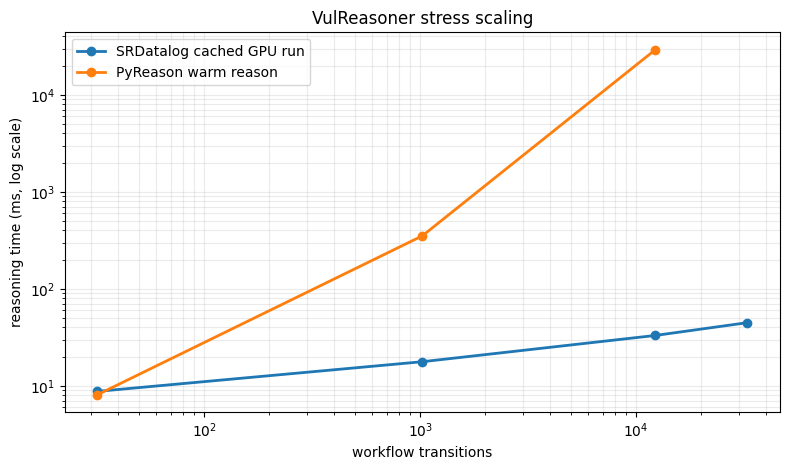

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.8))
gpu_plot = benchmark_df.dropna(subset=['SRDatalog GPU run (ms)'])
py_plot = benchmark_df.dropna(subset=['PyReason reason (ms)'])
ax.loglog(gpu_plot['transitions'], gpu_plot['SRDatalog GPU run (ms)'], 'o-', linewidth=2, label='SRDatalog cached GPU run')
ax.loglog(py_plot['transitions'], py_plot['PyReason reason (ms)'], 'o-', linewidth=2, label='PyReason warm reason')
ax.set_xlabel('workflow transitions')
ax.set_ylabel('reasoning time (ms, log scale)')
ax.set_title('VulReasoner stress scaling')
ax.grid(True, which='both', alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusions

1. **The gap is semantic, not syntactic.** Boolean set semantics cannot express interval payloads, delayed keys, witness selection, and cross-rule information accumulation.
2. **The annotation callback is a grouped provenance-aware aggregate.** Tuple identities recover valid label/connector pairings; `ARG MAX(lower)` must carry the upper bound from the same witness.
3. **Two rules preserve two grouping levels.** A per-source-rule candidate relation selects one witness; only its delta is promoted into `AnalystAt`, where interval intersection combines rule winners.
4. **Two extra columns are sufficient for the range, but not for selection identity.** Candidate rows additionally carry stable connector rank; separate candidate relations encode rule identity.
5. **Correctness is exact on the supplied input.** The five temporal rows from PyReason and SRDatalog serialize to the same 135 bytes and SHA-256 `ae3d94e...b2d`.
6. **The scaling advantage appears once grounding grows.** In the recorded run, 1,024 transitions take about 353 ms in PyReason versus 17.7 ms on SRDatalog (~20×); 12,288 take 29.39 s versus 33.1 ms (~889×). SRDatalog handles 32,768 transitions in 44.6 ms, while the notebook intentionally stops expanding the PyReason oracle beyond its bounded policy.

Implementation sources: [`annotation_fn.py`](annotation_fn.py), [`analyst_rules.csv`](rules/analyst_rules.csv), [`srdatalog_query.py`](srdatalog_query.py), [`graphml_ingest.py`](graphml_ingest.py), and [`stress_workload.py`](stress_workload.py).